In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!rm -rf /content/Data_300
!rm -rf /content/Data_Full

!unzip -q /content/drive/MyDrive/AppML/jpegs_all_300m.zip -d /content/Data_300
print('Done unzipping')

Done unzipping


In [27]:
import os
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm.auto import tqdm

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
assert device.type == "cuda", "GPU not available — check Runtime > Change runtime type"

PyTorch 2.11.0+cu128
Using device: cuda


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURE THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_DIR    = '/content/Data_300'   # ← change this
IMG_SIZE    = 600
BATCH_SIZE  = 32
NUM_SAMPLES = -1
EPOCHS      = 50
LR          = 1e-3
VAL_SPLIT   = 0.2
DROPOUT     = 0.3
PATIENCE    = 10       # early stopping patience
OUTPUT_DIR  = "output"
SEED        = 42
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [9]:
def extract_target_from_filename(filename: str) -> int:
    """Return the last integer found in the filename (before extension)."""
    stem = Path(filename).stem
    numbers = re.findall(r"\d+", stem)
    if not numbers:
        raise ValueError(f"No numeric target found in filename: {filename}")
    return int(numbers[-1])


class PeopleCountDataset(Dataset):
    """Loads images from a directory; target = last number in filename."""

    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    target = extract_target_from_filename(f.name)
                    self.samples.append((f, target))
                except ValueError:
                    print(f"  ⚠ Skipping {f.name} — no target in name")

        if not self.samples:
            raise FileNotFoundError(
                f"No valid images in {root_dir}. Check the path and filename format."
            )

        targets = [t for _, t in self.samples]
        print(f"✓ Loaded {len(self.samples)} images")
        print(f"  Target range: {min(targets)} – {max(targets)}  "
              f"(mean {np.mean(targets):.1f}, std {np.std(targets):.1f})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [21]:
# Load full dataset
full_dataset = PeopleCountDataset(DATA_DIR, transform=None)
full_dataset.samples = full_dataset.samples[:NUM_SAMPLES]

# ── Balance: equal number of 0-people vs has-people ──────────
zero_samples = [s for s in full_dataset.samples if s[1] == 0]
nonzero_samples = [s for s in full_dataset.samples if s[1] > 0]

# Downsample the larger group to match the smaller group
n_balanced = min(len(zero_samples), len(nonzero_samples))
random.shuffle(zero_samples)
random.shuffle(nonzero_samples)
full_dataset.samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
random.shuffle(full_dataset.samples)

print(f"Balanced: {n_balanced} zero-people + {n_balanced} with-people = {len(full_dataset.samples)} total")
# ──────────────────────────────────────────────────────────────

val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size

train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dataset = PeopleCountDataset(DATA_DIR, transform=train_transform)
train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]

val_dataset = PeopleCountDataset.__new__(PeopleCountDataset)
val_dataset.root_dir = full_dataset.root_dir
val_dataset.transform = val_transform
val_dataset.samples = [full_dataset.samples[i] for i in val_subset.indices]

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
)

print(f"Train: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples")

✓ Loaded 9587 images
  Target range: 0 – 899  (mean 12.0, std 48.5)
Balanced: 3914 zero-people + 3914 with-people = 7828 total
✓ Loaded 9587 images
  Target range: 0 – 899  (mean 12.0, std 48.5)
Train: 6263 samples  |  Val: 1565 samples


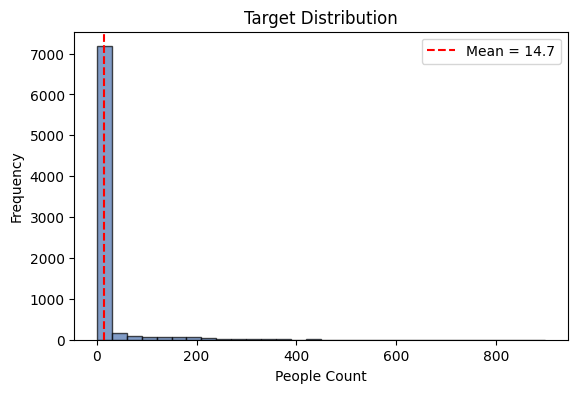

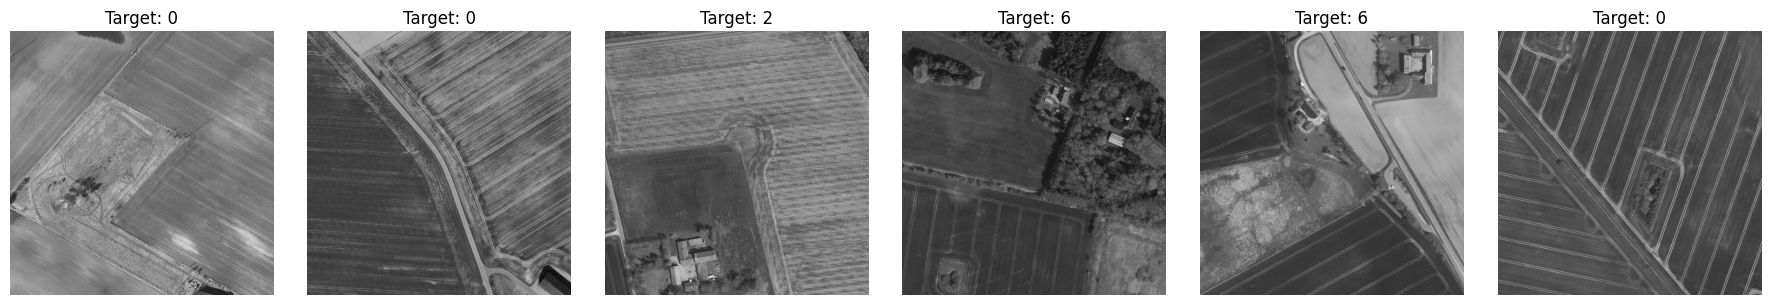

In [22]:
targets = [t for _, t in full_dataset.samples]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(targets, bins=30, edgecolor="black", alpha=0.7, color="#4C72B0")
axes[0].set_xlabel("People Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Target Distribution")
axes[0].axvline(np.mean(targets), color="red", linestyle="--", label=f"Mean = {np.mean(targets):.1f}")
axes[0].legend()

# Show a few sample images
sample_indices = random.sample(range(len(full_dataset)), min(6, len(full_dataset)))
axes[1].set_visible(False)

fig2, axes2 = plt.subplots(1, min(6, len(full_dataset)), figsize=(18, 3))
if not isinstance(axes2, np.ndarray):
    axes2 = [axes2]
for ax, idx in zip(axes2, sample_indices):
    path, target = full_dataset.samples[idx]
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ax.imshow(img)
    ax.set_title(f"Target: {target}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
class PeopleCountCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),    # 200 → 100
            conv_block(32, 64),   # 100 → 50
            conv_block(64, 128),  #  50 → 25
            conv_block(128, 256), #  25 → 12
        )

        self.pool = nn.AdaptiveAvgPool2d(1)  # → 256×1×1

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x).squeeze(-1)


model = PeopleCountCNN(dropout=DROPOUT).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 1,207,201
PeopleCountCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
     

In [24]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

In [25]:
# MPS workaround: some ops need float32 fallback
if device.type == "mps":
    import os
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in tqdm(loader, desc="  Training", leave=False):
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    return epoch_loss, mae


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        preds = model(imgs)
        loss = criterion(preds, targets)

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds) if len(set(all_targets)) > 1 else 0.0
    return epoch_loss, mae, r2, np.array(all_preds), np.array(all_targets)

In [26]:
best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

pbar = tqdm(range(1, EPOCHS + 1), desc="Training")

for epoch in pbar:
    train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_r2, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    pbar.set_postfix({
        "t_loss": f"{train_loss:.4f}",
        "v_loss": f"{val_loss:.4f}",
        "v_mae": f"{val_mae:.2f}",
        "v_r2": f"{val_r2:.3f}",
    })

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_mae": val_mae,
        }, os.path.join(OUTPUT_DIR, "best_model.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"\n✓ Training complete — best val loss: {best_val_loss:.4f}")

Training:   0%|          | 0/50 [00:00<?, ?it/s]

  Training:   0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 